In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_fraud_data.csv")

print(df.shape)

(283726, 31)


In [2]:
X = df.drop(columns="Class")
y = df["Class"]

print("X:", X.shape)
print("y:", y.shape)

X: (283726, 30)
y: (283726,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("\nTrain fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)

Train fraud rate: 0.0016653449643140364
Test fraud rate: 0.0016741268107003137


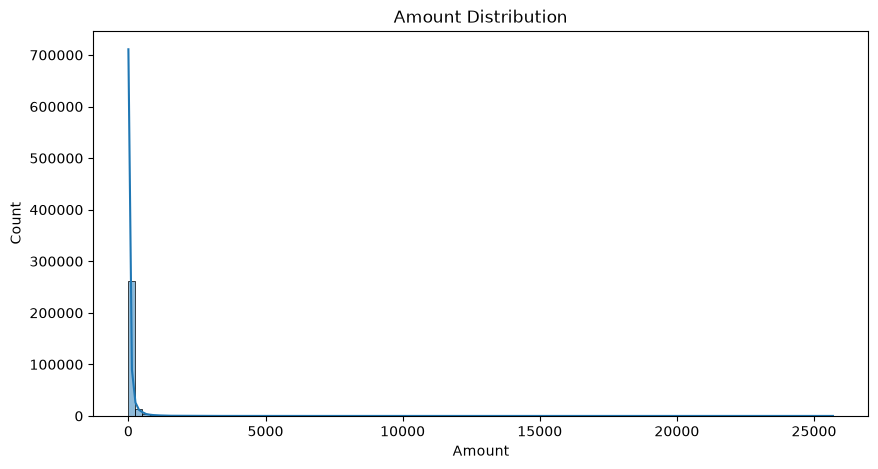

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=100, kde=True)
plt.title("Amount Distribution")
plt.show()

In [11]:
import numpy as np

X_train = X_train.copy()
X_test = X_test.copy()

X_train["LogAmount"] = np.log1p(X_train["Amount"])
X_test["LogAmount"] = np.log1p(X_test["Amount"])

print(X_train[["Amount", "LogAmount"]].head())

        Amount  LogAmount
225399   32.00   3.496508
133746    6.99   2.078191
185792   14.95   2.769459
148925   17.30   2.906901
18398    24.00   3.218876


In [12]:
X_train = X_train.drop(columns="Amount")
X_test = X_test.drop(columns="Amount")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Columns:", X_train.columns.tolist())

X_train: (226980, 30)
X_test: (56746, 30)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'LogAmount']


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (226980, 30)
X_test_scaled: (56746, 30)


In [14]:
import numpy as np

print("Train means:", np.round(X_train_scaled.mean(axis=0)[:5], 4))
print("Train stds:", np.round(X_train_scaled.std(axis=0)[:5], 4))

Train means: [-0.  0. -0.  0. -0.]
Train stds: [1. 1. 1. 1. 1.]


In [15]:
import pandas as pd

train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_df["Class"] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
test_df["Class"] = y_test.values

train_df.to_csv("../data/processed/train_features.csv", index=False)
test_df.to_csv("../data/processed/test_features.csv", index=False)

print(train_df.shape)
print(test_df.shape)

(226980, 31)
(56746, 31)


In [16]:
import os

print("Train file exists:", os.path.exists("../data/processed/train_features.csv"))
print("Test file exists:", os.path.exists("../data/processed/test_features.csv"))

Train file exists: True
Test file exists: True
